## Linear Regression Manually calculates

### ***ASSIGNMENT NO : 08***

### Import Libraries

In [16]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

### Load Data

In [17]:
# Load dataset
df = pd.read_csv("archive/BostonHousing.csv")

In [18]:
df.isnull().sum()

Crime_rate    0
zn            0
indus         0
chas          0
nox           0
rm            5
Age           0
Distance      0
rad           0
tax           0
ptratio       0
b             0
lstat         0
medv          0
dtype: int64

In [45]:
df.columns

Index(['Crime_rate', 'zn', 'indus', 'chas', 'nox', 'rm', 'Age', 'Distance',
       'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

In [19]:
rm_mean = df['rm'].mean()
df['rm'].fillna(rm_mean, inplace = True)

C:\Users\Prathamesh\AppData\Local\Temp\ipykernel_10608\986817063.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rm'].fillna(rm_mean, inplace = True)


In [20]:
df.isnull().sum()

Crime_rate    0
zn            0
indus         0
chas          0
nox           0
rm            0
Age           0
Distance      0
rad           0
tax           0
ptratio       0
b             0
lstat         0
medv          0
dtype: int64

In [21]:
# seperate input and output attribute's
X = df.drop("medv", axis=1).values   # inputs
y = df["medv"].values               # output

### Train-Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

### Build Model Class (MULTIPLE LINEAR REGRESSION)

In [47]:
import numpy as np

class LinearRegressionMulti:
    
    def __init__(self):
        self.weights = None
        self.bias = None

    # 🔹 Forward Propagation
    def forward(self, X):
        return np.dot(X, self.weights) + self.bias

    # 🔹 Cost Function (MSE)
    def cost(self, y_pred, y):
        return np.mean((y - y_pred) ** 2)

    # 🔹 Backward Propagation
    def backward(self, X, y, y_pred):
        n = X.shape[0]

        dw = (2/n) * np.dot(X.T, (y_pred - y))
        db = (2/n) * np.sum(y_pred - y)

        return dw, db

    # 🔹 Update Parameters
    def update(self, dw, db, lr):
        self.weights -= lr * dw
        self.bias -= lr * db

    # 🔹 Training Function
    def train(self, X, y, lr=0.0001, iters=1000):
        n_features = X.shape[1]

        self.weights = np.zeros(n_features)
        self.bias = 0

        for i in range(iters):
            y_pred = self.forward(X)

            cost = self.cost(y_pred, y)

            dw, db = self.backward(X, y, y_pred)

            self.update(dw, db, lr)

            if i % 100 == 0:
                print(f"Iteration {i}, Loss = {cost}")

    # -------------------------------------------------------------------------------------------------------------------
    # This is not required only for understanding
    # -------------------------------------------------------------------------------------------------------------------
    def print_equation(self, feature_names=None):
        print("\n Linear Regression Equation:\n")
        
        equation = "y = "
        
        for i, w in enumerate(self.weights):
            if feature_names:
                equation += f"({w:.4f} * {feature_names[i]}) + "
            else:
                equation += f"({w:.4f} * x{i}) + "
        
        equation += f"{self.bias:.4f}"
        
        print(equation)
        
        print("\n Coefficients:")
        for i, w in enumerate(self.weights):
            if feature_names:
                print(f"{feature_names[i]}: {w:.4f}")
            else:
                print(f"x{i}: {w:.4f}")
        
        print(f"\nIntercept (bias): {self.bias:.4f}")

### FEATURE SCALING

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Train Model

In [49]:
model = LinearRegressionMulti()
model.train(X_train, y_train, lr=0.05, iters=7000)

Iteration 0, Loss = 606.5553960396039
Iteration 100, Loss = 21.903519857890927
Iteration 200, Loss = 21.73316425592861
Iteration 300, Loss = 21.699006067221934
Iteration 400, Loss = 21.689893505150863
Iteration 500, Loss = 21.68736132442304
Iteration 600, Loss = 21.686654219382383
Iteration 700, Loss = 21.686456647052424
Iteration 800, Loss = 21.686401439519948
Iteration 900, Loss = 21.686386012781107
Iteration 1000, Loss = 21.68638170205584
Iteration 1100, Loss = 21.686380497500895
Iteration 1200, Loss = 21.6863801609096
Iteration 1300, Loss = 21.68638006685519
Iteration 1400, Loss = 21.68638004057337
Iteration 1500, Loss = 21.686380033229383
Iteration 1600, Loss = 21.686380031177237
Iteration 1700, Loss = 21.686380030603804
Iteration 1800, Loss = 21.686380030443566
Iteration 1900, Loss = 21.686380030398787
Iteration 2000, Loss = 21.68638003038628
Iteration 2100, Loss = 21.686380030382786
Iteration 2200, Loss = 21.686380030381805
Iteration 2300, Loss = 21.68638003038154
Iteration 2400

### Prediction

In [50]:
y_pred = model.forward(X_test)

### Linear Regression Equation

In [51]:
feature_names = [
    'Crime_rate', 'zn', 'indus', 'chas', 'nox', 'rm',
    'Age', 'Distance', 'rad', 'tax', 'ptratio', 'b', 'lstat'
]
model.print_equation(feature_names)


 Linear Regression Equation:

y = (-1.0021 * Crime_rate) + (0.6986 * zn) + (0.2873 * indus) + (0.7196 * chas) + (-2.0207 * nox) + (3.1371 * rm) + (-0.1708 * Age) + (-3.0697 * Distance) + (2.2542 * rad) + (-1.7670 * tax) + (-2.0436 * ptratio) + (1.1294 * b) + (-3.6145 * lstat) + 22.7965

 Coefficients:
Crime_rate: -1.0021
zn: 0.6986
indus: 0.2873
chas: 0.7196
nox: -2.0207
rm: 3.1371
Age: -0.1708
Distance: -3.0697
rad: 2.2542
tax: -1.7670
ptratio: -2.0436
b: 1.1294
lstat: -3.6145

Intercept (bias): 22.7965


### Evaluation

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)


Mean Squared Error: 24.404981751576507
R2 Score: 0.6672068356514197


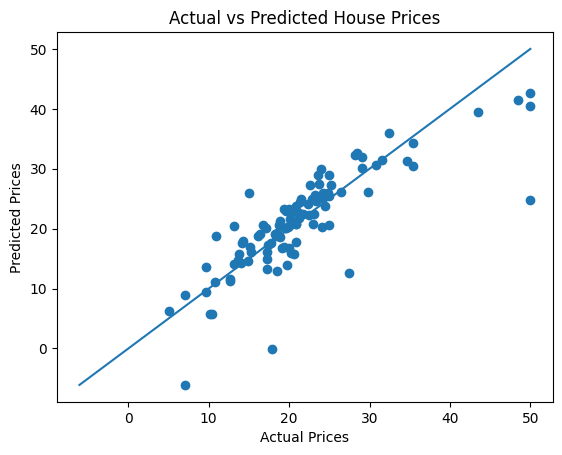

In [39]:
# Plot
plt.scatter(y_test, y_pred)

# Perfect fit line
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()